In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ==========================================
# STEP 1: IMPORTS & DATA ACQUISITION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Fetch Data (You can change 'AAPL' to your preferred ticker like '^NSEI' for Nifty 50)
ticker = 'AAPL'  
df = yf.download(ticker, start='2018-01-01', end='2024-01-01')
df.ffill(inplace=True) # Forward fill any missing values

print(f"Data for {ticker} Fetched Successfully! Total records: {len(df)}")

[*********************100%***********************]  1 of 1 completed

Data for AAPL Fetched Successfully! Total records: 1509


In [4]:
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


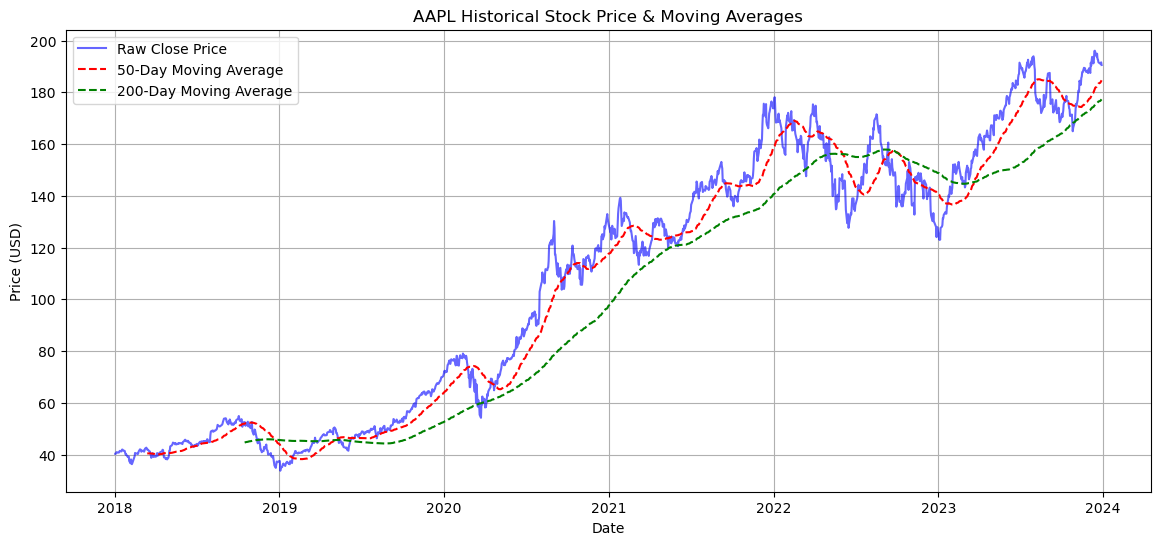

In [5]:
# ==========================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Calculate Moving Averages for visual analysis
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Raw Close Price', color='blue', alpha=0.6)
plt.plot(df.index, df['MA50'], label='50-Day Moving Average', color='red', linestyle='--')
plt.plot(df.index, df['MA200'], label='200-Day Moving Average', color='green', linestyle='--')

plt.title(f'{ticker} Historical Stock Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Drop the Moving Averages so they don't interfere with our Deep Learning model
df.drop(['MA50', 'MA200'], axis=1, inplace=True)

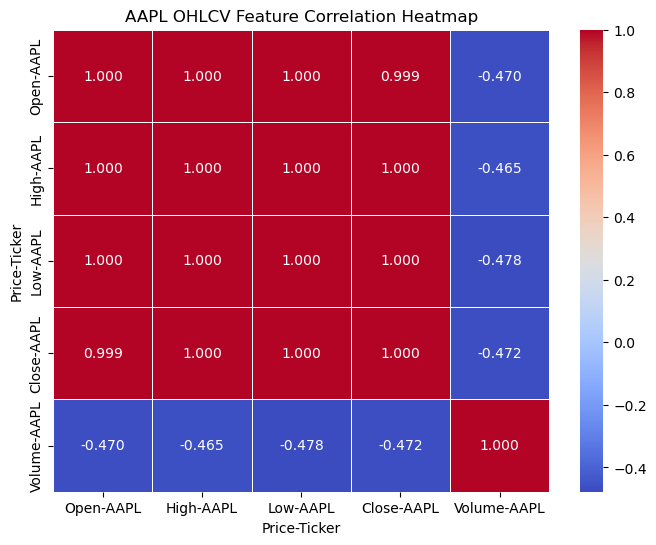

In [6]:
# ==========================================
#  CORRELATION HEATMAP
# ==========================================
import seaborn as sns

plt.figure(figsize=(8, 6))
# Calculate the correlation matrix for the 5 features
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title(f'{ticker} OHLCV Feature Correlation Heatmap')
plt.show()

In [7]:
# ==========================================
# STEP 3: FEATURE SELECTION & SPLITTING
# ==========================================
# 1. Select all 5 OHLCV features mentioned in your report
features = ['Close', 'Open', 'High', 'Low', 'Volume']
data = df[features].values

# 2. Split the raw data FIRST (80/20) to prevent Data Leakage
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print(f"Data Split Complete! Train size: {len(train_data)}, Test size: {len(test_data)}")

Data Split Complete! Train size: 1207, Test size: 302


In [8]:
# ==========================================
# STEP 4: TWO-SCALER PREPROCESSING & SEQUENCES
# ==========================================
# Scaler for ALL 5 features (OHLCV)
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler_features.fit_transform(train_data)
scaled_test = scaler_features.transform(test_data)

# Scaler ONLY for the target variable ('Close' is at index 0)
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(train_data[:, 0].reshape(-1, 1)) 

# Function to create sequences of 60 days of 5 features
def create_multivariate_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), :]) # Take all 5 columns
        y.append(dataset[i + time_step, 0])     # Predict only 'Close'
    return np.array(X), np.array(y)

X_train, y_train = create_multivariate_dataset(scaled_train, 60)
X_test, y_test = create_multivariate_dataset(scaled_test, 60)

print(f"Sequences Ready! X_train shape: {X_train.shape} (Samples, Timesteps, Features)")

Sequences Ready! X_train shape: (1146, 60, 5) (Samples, Timesteps, Features)


In [9]:
# ==========================================
# STEP 5: MULTIVARIATE STACKED LSTM 
# ==========================================
model_stacked = Sequential()

# Layer 1: Automatically adapts to the 5 features
model_stacked.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_stacked.add(Dropout(0.1))

# Layer 2
model_stacked.add(LSTM(64, return_sequences=False))
model_stacked.add(Dropout(0.1))

# Output Layers
model_stacked.add(Dense(25))
model_stacked.add(Dense(1)) # Output is a single value (Predicted Close)

# Compile
optimizer = Adam(learning_rate=0.001)
model_stacked.compile(optimizer=optimizer, loss='mean_squared_error')

# Early Stopping avoids overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training Multivariate Stacked LSTM...")
history = model_stacked.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=100, 
    batch_size=16, 
    verbose=1, 
    callbacks=[early_stop]
)
print("✅ Training Complete!")

Training Multivariate Stacked LSTM...
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0152 - val_loss: 0.0045
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0019 - val_loss: 9.7355e-04
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0015 - val_loss: 9.6013e-04
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0016 - val_loss: 9.7242e-04
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0014 - val_loss: 0.0057
Epoch 11/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0016 - val_loss: 8.0100e-0

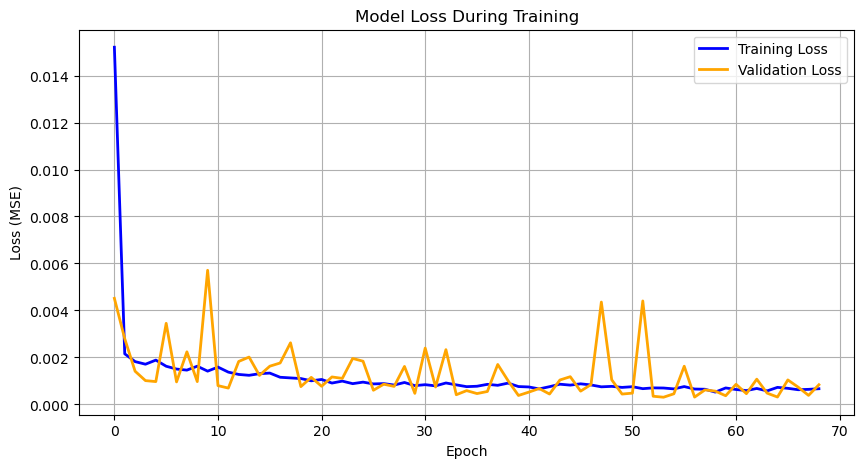

In [10]:
# ==========================================
# STEP 6: TRAINING LOSS GRAPH (LEARNING CURVE)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# ==========================================
# STEP 7: EVALUATION METRICS & TEST GRAPH
# ==========================================
# 1. Predict
pred_stacked = model_stacked.predict(X_test)

# 2. Reverse scaling to get actual USD values using scaler_target
pred_stacked = scaler_target.inverse_transform(pred_stacked)
y_test_actual = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate IEEE Report Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_stacked))
mae = mean_absolute_error(y_test_actual, pred_stacked)
r2 = r2_score(y_test_actual, pred_stacked)

print("\n--- FINAL EVALUATION METRICS (For Table IV) ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")



8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

--- FINAL EVALUATION METRICS (For Table IV) ---
RMSE: 2.53
MAE: 2.02
R2 Score: 0.9737


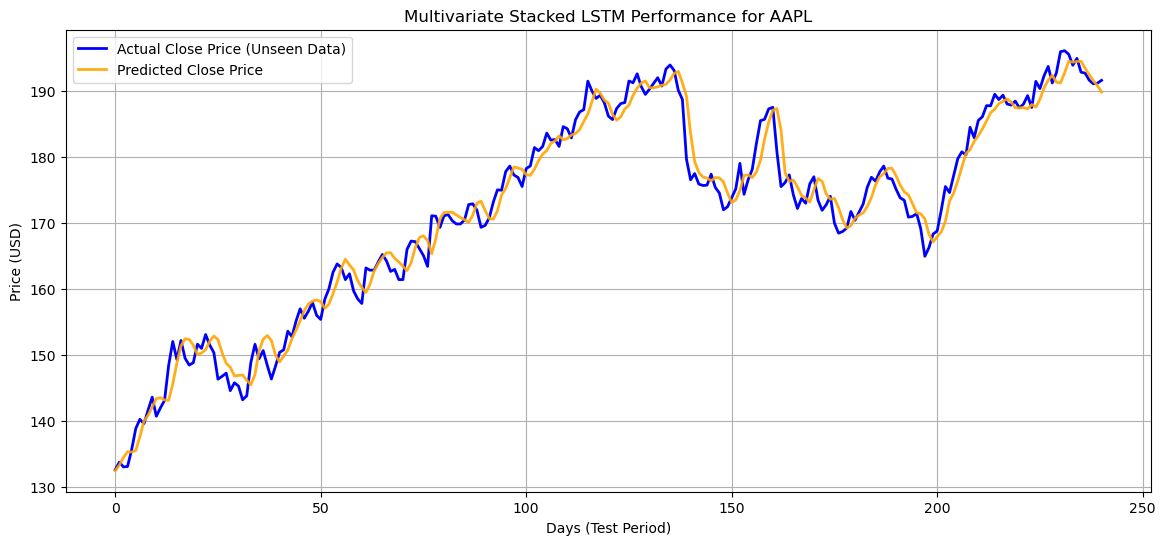

In [12]:
# 4. Zoomed-In Test Graph
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Close Price (Unseen Data)', color='blue', linewidth=2)
plt.plot(pred_stacked, label='Predicted Close Price', color='orange', linewidth=2, alpha=0.9)
plt.title(f'Multivariate Stacked LSTM Performance for {ticker}')
plt.xlabel('Days (Test Period)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

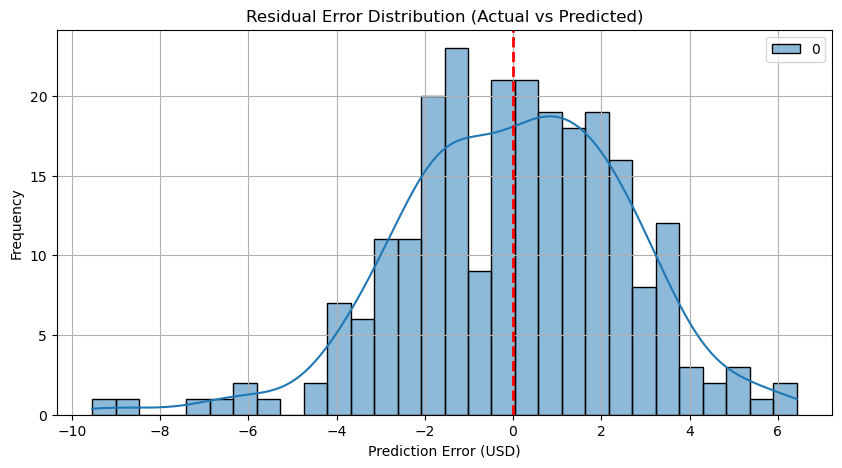

Observation: A good model has residuals centered around 0 (the red dotted line).


In [13]:
# ==========================================
# RESIDUAL ERROR PLOT
# ==========================================
import seaborn as sns

# Calculate the errors (Actual Price - Predicted Price)
residuals = y_test_actual - pred_stacked

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Error Distribution (Actual vs Predicted)')
plt.xlabel('Prediction Error (USD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("Observation: A good model has residuals centered around 0 (the red dotted line).")

In [14]:
# ==========================================
# STEP 8A: GENERATE 30-DAY FUTURE FORECAST
# ==========================================
print("\n--- Generating 30-Day Future Forecast ---")

# Start with the last 60 days of the dataset (all 5 features scaled)
last_60_days = scaler_features.transform(data[-60:])
current_batch = last_60_days.reshape(1, 60, 5)

forecast_30 = []

for i in range(30):
    # Predict tomorrow's Close
    next_pred_close = model_stacked.predict(current_batch, verbose=0)
    forecast_30.append(next_pred_close[0, 0])
    
    # Create the new row for the next day, assuming other features stay stable
    new_row = np.zeros(5)
    new_row[0] = next_pred_close[0, 0] # Insert our predicted Close
    new_row[1:] = current_batch[0, -1, 1:] # Copy previous Open/High/Low/Volume
    
    # Slide the window forward by 1 day
    new_row_reshaped = new_row.reshape(1, 1, 5)
    current_batch = np.append(current_batch[:, 1:, :], new_row_reshaped, axis=1)

# Reverse scaling to convert predictions back to actual USD/Rupee values
forecast_30_actual = scaler_target.inverse_transform(np.array(forecast_30).reshape(-1, 1))

print("✅ 30-Day Forecast Generated Successfully!")


--- Generating 30-Day Future Forecast ---
✅ 30-Day Forecast Generated Successfully!


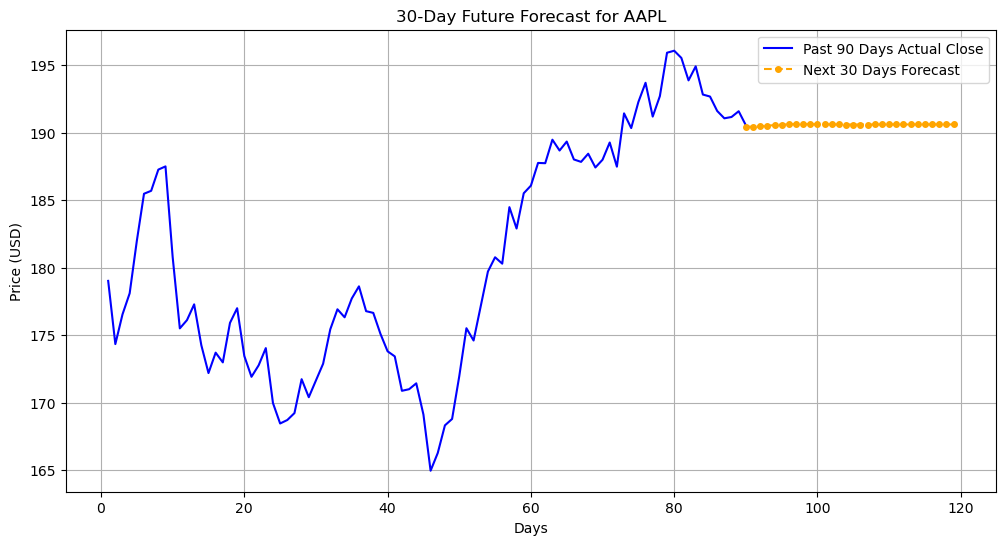

In [15]:
# ==========================================
# STEP 8B: VISUALIZE THE FORECAST
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Define how many past days you want to show on the graph
past_days = 90 

# Plot the Actual past data (Blue line)
plt.plot(range(1, past_days + 1), data[-past_days:, 0], label=f'Past {past_days} Days Actual Close', color='blue')

# Plot the Forecasted future data (Orange dotted line)
plt.plot(range(past_days, past_days + 30), forecast_30_actual, label='Next 30 Days Forecast', color='orange', linestyle='dashed', marker='o', markersize=4)

# Graph Formatting
plt.title(f'30-Day Future Forecast for {ticker}')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ==========================================
# STEP 9: SAVE THE TRAINED MODEL
# ==========================================
import os

# Create a folder to save models if it doesn't exist
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Save the Multivariate Stacked LSTM model
model_filename = f"saved_models/{ticker}_multivariate_lstm_model.h5"
model_stacked.save(model_filename)

print(f"✅ Model successfully saved to: {model_filename}")
print("You can load this later using tf.keras.models.load_model()")

✅ Model successfully saved to: saved_models/AAPL_multivariate_lstm_model.h5
You can load this later using tf.keras.models.load_model()


In [17]:
direction_actual = np.sign(np.diff(y_test_actual.flatten()))
direction_pred = np.sign(np.diff(pred_stacked.flatten()))

direction_acc = np.mean(direction_actual == direction_pred) * 100

print(f"Direction Accuracy: {direction_acc:.2f}%")

Direction Accuracy: 50.00%
